In [3]:
#Import everything
import matplotlib.pyplot as plt
import numpy as np
from pymatgen.core.structure import Structure, Lattice, IStructure
from pymatgen.io.vasp import Kpoints
from pymatgen.util.coord import get_angle
import matplotlib as mpl
import cmath
import TBLR2 as TBLR
import tqdm as tqdm
from matplotlib.collections import LineCollection
import matplotlib.patheffects as pe
from tqdm import tqdm
from pymatgen.io.vasp.outputs import Outcar
#from sympy import *
#from sympy import init_printing
#init_printing(use_unicode=True)
#from sympy import symbols
from sympy.matrices import Matrix
import pythtb
from pythtb import * # import TB model class
import matplotlib.pyplot as plt
import pandas as pd

#from sympy.physics.quantum import TensorProduct


----- k_path report begin ----------
real-space lattice vectors
 [[ 4.18899  2.41851  7.35805]
 [-4.18899  2.41851  7.35805]
 [ 0.      -4.83703  7.35805]]
k-space metric tensor
 [[ 0.02105 -0.00745 -0.00745]
 [-0.00745  0.02105 -0.00745]
 [-0.00745 -0.00745  0.02105]]
internal coordinates of nodes
 [[ 0.       0.       0.     ]
 [ 0.5      0.5      0.5    ]
 [ 0.5     -0.23869  0.23869]
 [ 0.5      0.       0.     ]
 [ 0.       0.       0.     ]
 [ 0.36935 -0.36935  0.     ]
 [ 0.5      0.       0.5    ]
 [ 0.       0.       0.     ]]
reciprocal-space lattice vectors
 [[ 1.19361e-01  6.89129e-02  4.53018e-02]
 [-1.19361e-01  6.89129e-02  4.53018e-02]
 [ 4.65592e-18 -1.37826e-01  4.53018e-02]]
cartesian coordinates of nodes
 [[ 0.00000e+00  0.00000e+00  0.00000e+00]
 [-4.61094e-18  0.00000e+00  6.79528e-02]
 [ 8.81706e-02 -1.48902e-02  2.26509e-02]
 [ 5.96803e-02  3.44564e-02  2.26509e-02]
 [ 0.00000e+00  0.00000e+00  0.00000e+00]
 [ 8.81706e-02 -1.31936e-18 -1.43256e-18]
 [ 5.96803e-0

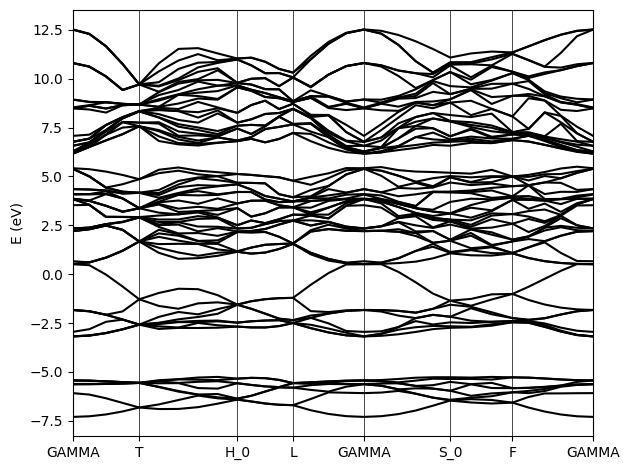

In [2]:
#Create pythTB from wannier
#dir ="/projects/SCHOOP/gc2596/Wannier_test/Diamond/wannier"
calc_dir = "/projects/SCHOOP/gc2596/Wannier_test/GeTe"
wann_dir = calc_dir+"/wannier"
band_dir = calc_dir+"/band"
OUTCAR = Outcar(wann_dir+"/OUTCAR")
mu = OUTCAR.efermi
# evals=my_model.sol
wannier_material=w90(wann_dir,r"wannier90")
crys_struct = Structure.from_file(wann_dir+"/POSCAR")
my_model=wannier_material.model(min_hopping_norm=0.001) # get tight-binding model without hopping terms above 0.01 eV

#con_trans=2*np.array([[-1,1,1],[1,-1,1],[1,1,-1]]) #Diamond primitive to conventional.. 
#con_trans =np.array([[-1,1,1],[1,-1,1],[1,1,-1]]) #NaCl primitive to conventional..
#con_trans =np.array([[2,1,0],[-2,1,0],[0,0,1]])
#con_trans =np.array([[2,0,0],[0,2,0],[0,0,2]])
#my_model = my_model.make_supercell(np.array(con_trans))
my_model = my_model.make_supercell(np.array([[2,0,0],[0,2,0],[0,0,2]]))

kpoints = Kpoints.from_file(band_dir+"/KPOINTS")
#kpoints.labels
#kpoints.kpts
kpoint_list = kpoints.kpts[::2]
kpoint_list.append(kpoints.kpts[-1])
kpoint_labels=kpoints.labels[::2]
kpoint_labels.append(kpoints.labels[-1])

(k_vec,k_dist,k_node)=my_model.k_path(kpoint_list,31)

evals=my_model.solve_all(k_vec)
fig, ax = plt.subplots()
for i in range(evals.shape[0]):
    ax.plot(k_dist,evals[i],"k-")
for n in range(len(k_node)):
    ax.axvline(x=k_node[n],linewidth=0.5, color='k')



ax.set_xlabel("")
ax.set_ylabel("E (eV)")
ax.set_xlim(k_dist[0],k_dist[-1])
ax.set_xticks(k_node)
ax.set_xticklabels(kpoint_labels)
fig.tight_layout()

In [29]:
my_model._lat
my_model._orb[::4]

my_model._site_energies[::4]
energy_to_element = {my_model._site_energies[::4][0]:'Ge',
                     my_model._site_energies[::4][1]:'Te'}

element_list=[]
for item in my_model._site_energies[::4]:
    element_list.append(energy_to_element.__getitem__(item))
doubled_struct = Structure(my_model._lat,element_list,my_model._orb[::4])
doubled_struct.to(filename=wann_dir+"/2x2x2_struct.cif",fmt="cif")


"# generated using pymatgen\ndata_GeTe\n_symmetry_space_group_name_H-M   'P 1'\n_cell_length_a   8.80555149\n_cell_length_b   8.80555149\n_cell_length_c   8.80555155\n_cell_angle_alpha   56.81262469\n_cell_angle_beta   56.81262469\n_cell_angle_gamma   56.81262472\n_symmetry_Int_Tables_number   1\n_chemical_formula_structural   GeTe\n_chemical_formula_sum   'Ge8 Te8'\n_cell_volume   447.27171800\n_cell_formula_units_Z   8\nloop_\n _symmetry_equiv_pos_site_id\n _symmetry_equiv_pos_as_xyz\n  1  'x, y, z'\nloop_\n _atom_site_type_symbol\n _atom_site_label\n _atom_site_symmetry_multiplicity\n _atom_site_fract_x\n _atom_site_fract_y\n _atom_site_fract_z\n _atom_site_occupancy\n  Ge  Ge0  1  -0.00277022  -0.00277022  -0.00276661  1\n  Te  Te1  1  -0.23679503  -0.23679503  -0.23679746  1\n  Ge  Ge2  1  -0.00277022  -0.00277022  0.49723339  1\n  Te  Te3  1  -0.23679503  -0.23679503  0.26320254  1\n  Ge  Ge4  1  -0.00277022  0.49722978  -0.00276661  1\n  Te  Te5  1  -0.23679503  0.26320497  -0.2

In [26]:
doubled_struct

Structure Summary
Lattice
    abc : 8.805551485011916 8.805551485011916 8.805551548228408
 angles : 56.81262468794596 56.81262468794596 56.81262471716656
 volume : 447.27171800136904
      A : 4.1889868 2.4185126 7.3580516
      B : -4.1889868 2.4185126 7.3580516
      C : 0.0 -4.8370254 7.3580516
    pbc : True True True
PeriodicSite: Ge (-1.135e-18, -1.746e-05, -0.06112) [-0.00277, -0.00277, -0.002767]
PeriodicSite: Te (-8.876e-17, 1.179e-05, -5.227) [-0.2368, -0.2368, -0.2368]
PeriodicSite: Ge (-1.135e-18, -2.419, 3.618) [-0.00277, -0.00277, 0.4972]
PeriodicSite: Te (-8.876e-17, -2.419, -1.548) [-0.2368, -0.2368, 0.2632]
PeriodicSite: Ge (-2.094, 1.209, 3.618) [-0.00277, 0.4972, -0.002767]
PeriodicSite: Te (-2.094, 1.209, -1.548) [-0.2368, 0.2632, -0.2368]
PeriodicSite: Ge (-2.094, -1.209, 7.297) [-0.00277, 0.4972, 0.4972]
PeriodicSite: Te (-2.094, -1.209, 2.131) [-0.2368, 0.2632, 0.2632]
PeriodicSite: Ge (2.094, 1.209, 3.618) [0.4972, -0.00277, -0.002767]
PeriodicSite: Te (2.094, 1

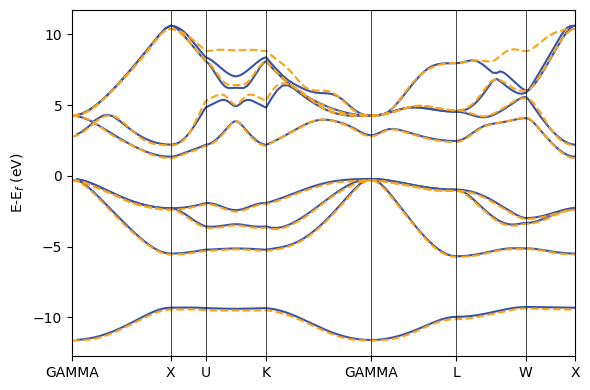

In [7]:
OUTCAR = Outcar(wann_dir+"/OUTCAR")
mu = OUTCAR.efermi
# evals=my_model.solve_all(k_vec)
fig, ax = plt.subplots()

K_labels=pd.read_csv(band_dir+"/KLABELS",delim_whitespace=True,comment="#")
band = pd.DataFrame(pd.read_csv(band_dir+"/REFORMATTED_BAND.dat",delim_whitespace=True,comment='#'))


for i in band.columns[1:]:
    ax.plot(band[band.columns[0]]*(k_dist[-1]/np.array(band[band.columns[0]])[-1]),band[i],color="#3953a4")
#ax.set_xlim(list(K_labels['Coordinate'])[0],list(K_labels['Coordinate'])[-1])

for i in range(evals.shape[0]):
    ax.plot(k_dist,evals[i]-mu,color="#faa316",linestyle="dashed")
for n in range(len(k_node)):
    ax.axvline(x=k_node[n],linewidth=0.5, color='k')


ax.set_xlabel("")
ax.set_ylabel(r"$E-E_f \quad(eV)$")
ax.set_xlim(k_dist[0],k_dist[-1])
ax.set_xticks(ticks=K_labels['Coordinate']*(k_dist[-1]/np.array(band[band.columns[0]])[-1]),labels=kpoint_labels)

#ax.set_xticks(k_node)
#ax.set_xticklabels(k_label)
plt.gcf().set_size_inches(6,4)
#plt.gcf().set_size_inches(8,5)
#plt.ylim(-13,6)
plt.ylabel(r"E-E$_f$ (eV)")
fig.tight_layout()
plt.savefig(wann_dir+"/Wannier_DFT_compare.png",dpi=400,bbox_inches='tight')  




In [16]:
K_labels

,K-Label,Coordinate
0,GAMMA,0.000
1,T,0.295
2,H_2,1.237
3,H_0,1.439
4,L,1.950
5,GAMMA,2.795
6,S_0,3.776
7,S_2,3.974
8,F,4.445
9,GAMMA,5.307


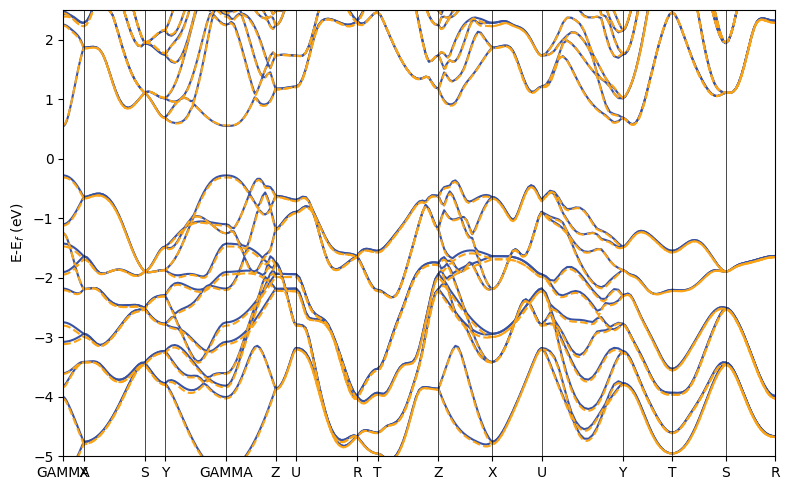

In [7]:
# evals=my_model.solve_all(k_vec)
fig, ax = plt.subplots()

dir = "/projects/SCHOOP/gc2596/Wannier_test/GeSe_2/band"
K_labels=pd.read_csv("/projects/SCHOOP/gc2596/Wannier_test/GeSe_2/band/KLABELS",delim_whitespace=True,comment="#")
band = pd.DataFrame(pd.read_csv(dir+"/REFORMATTED_BAND.dat",delim_whitespace=True,comment='#'))


for i in band.columns[1:]:
    ax.plot(band[band.columns[0]]*(k_dist[-1]/np.array(band[band.columns[0]])[-1]),band[i],color="#3953a4")
#ax.set_xlim(list(K_labels['Coordinate'])[0],list(K_labels['Coordinate'])[-1])
ax.set_xticks(ticks=K_labels['Coordinate']*(k_dist[-1]/np.array(band[band.columns[0]])[-1]),labels=K_labels['K-Label'])

for i in range(evals.shape[0]):
    ax.plot(k_dist,evals[i]-3.8960,color="#faa316",linestyle="dashed")
for n in range(len(k_node)):
    ax.axvline(x=k_node[n],linewidth=0.5, color='k')


ax.set_xlabel("")
ax.set_ylabel(r"$E-E_f \quad(eV)$")
ax.set_xlim(k_dist[0],k_dist[-1])
#ax.set_xticks(k_node)
#ax.set_xticklabels(k_label)
#plt.gcf().set_size_inches(4,2.5)
plt.gcf().set_size_inches(8,5)
plt.ylim(-5,2.5)
plt.ylabel(r"E-E$_f$ (eV)")
fig.tight_layout()
plt.savefig("/projects/SCHOOP/gc2596/Wannier_test/GeSe_2/wannier/Wannier_DFT_compare.png",dpi=400,bbox_inches='tight')  


In [ ]:
#evals=my_model.solve_all(k_vec)
fig, ax = plt.subplots()

dir = "/projects/SCHOOP/gc2596/localization_Ram/Si/tut_bandstruct_Si_GW/p4_bandstructure/"
K_labels=pd.read_csv("/projects/SCHOOP/gc2596/localization_Ram/Si/tut_bandstruct_Si_GW/p4_bandstructure/KLABELS",delim_whitespace=True,comment="#")
band = pd.DataFrame(pd.read_csv(dir+"/REFORMATTED_BAND.dat",delim_whitespace=True,comment='#'))


for i in band.columns[1:]:
    ax.plot(band[band.columns[0]]*(k_dist[-1]/np.array(band[band.columns[0]])[-1]),band[i],color="#3953a4")
#ax.set_xlim(list(K_labels['Coordinate'])[0],list(K_labels['Coordinate'])[-1])
ax.set_xticks(ticks=K_labels['Coordinate']*(k_dist[-1]/np.array(band[band.columns[0]])[-1]),labels=K_labels['K-Label'])

for i in range(evals.shape[0]):
    ax.plot(k_dist,evals[i]- 5.6395,color="#faa316")#,linestyle="dashed")
for n in range(len(k_node)):
    ax.axvline(x=k_node[n],linewidth=0.5, color='k')


ax.set_xlabel("")
ax.set_ylabel(r"$E-E_f \quad(eV)$")
ax.set_xlim(k_dist[0],k_dist[-1])
#ax.set_xticks(k_node)
#ax.set_xticklabels(k_label)
#plt.gcf().set_size_inches(4,2.5)
plt.gcf().set_size_inches(8,5)

plt.ylim(-15,10)
plt.ylabel(r"E-E$_f$ (eV)")
fig.tight_layout()
plt.savefig("/projects/SCHOOP/gc2596/localization_Ram/Si/tut_bandstruct_Si_GW/p4_bandstructure/Si_Wannier_DFT_compare.png",dpi=400,bbox_inches='tight')  

#get nelec from OUTCAR to get occ

In [37]:
#Create array with all hopping information
H = np.empty((my_model._norb,my_model._norb), dtype=object)
for i in range(len(H)):
    for j in range(len(H)):
        H[i,j] = []
orb_pos = my_model._orb
abs_dist_list = []
t_list=[]
for hop in my_model._hoppings:
    t,i,j,j_image = hop
    dist = ((my_model._orb[j]+j_image)-my_model._orb[i])@my_model._lat
    abs_dist = np.linalg.norm(dist)
    abs_dist_list.append(abs_dist)
    t_list.append(t)
    H[i,j].append([t,dist[0],dist[1],dist[2]])

In [38]:
#Function that finds hamiltonian from hopping array at specific k-point
def ham_func(k):
    kx,ky,kz=k
    H_res = np.zeros((my_model._norb,my_model._norb),dtype = complex)
    for i in np.arange(0,my_model._norb,1):
        for j in np.arange(0,my_model._norb):
            if len(H[i][j]) == 0:
                pass 
            else:
                for item in H[i][j]:
                    item0=complex(item[0])
                    item1=complex(item[1])
                    item2=complex(item[2])
                    item3=complex(item[3])
                    H_res[i][j] += np.round(item0,10)*(np.exp(1j* kx *item1+ 1j* ky *item2 +1j* kz *item3))
                    H_res[j][i] += np.conj(np.round(item0,10)*(np.exp(1j* kx *item1+ 1j* ky *item2 +1j* kz *item3)))
    for i,onsite in enumerate(my_model._site_energies):
        H_res[i,i]+=np.round(onsite,10)
    return H_res

mu 5.9873


/tmp/ipykernel_1138299/2053630059.py:28: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  plt.xlim(klabels[0],klabels[-1])


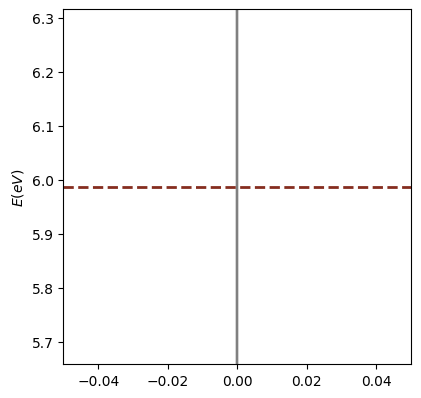

In [39]:
#Make tight-binding object in Nish's code
nkpx=1#change these depending on lattice (automate???)
nkpy=1
nkpz=1
lat = my_model.get_lat()
tb = TBLR.TBLinearResponse(ham_func, Lar=np.array(lat), 
                           Nkp=[nkpx,nkpy,nkpz],    # the first entry is number of points for line cuts and second entry is mesh size (200x200)
                           prestr='Diamond_super',   # this is an preffix identifier for filenames -- be sure to change it when changing parameters!
                           save_all=False,   # if true, it will i/o data from dataEnUm/ -- it speeds up the code!
                           kpath = ['G', 'X', 'M', 'G','Y','M'],   # high symmetry path for band structure plots   
                           )
#occ=4*2*2*2#int(1) #Change this based on lattice (automate using pymatgen??)
occ = int(len(tb.enUM[0,:,0][tb.enUM[0,:,0]<=mu]))

#tb.find_mu(occ=10)
print("mu",mu)
path=kpoint_list
klabels=kpoint_labels
evals, evecs,klabels= tb.solve_alongpath3D(path=path) 
evecs = np.array(evecs)
plt.plot(evals, 'k',linewidth=2)

#make orbital resolved bandstructure ()
#make site-resolved bandstructure??()

k_index = np.arange(0,np.shape(evals)[0])

plt.xlim(klabels[0],klabels[-1])
plt.ylabel(r'$E (eV)$')
for k in klabels:
    plt.axvline(k,color="grey")
plt.axhline(mu,linestyle="dashed",color="#852D1F",linewidth=2)
plt.tight_layout()
plt.gcf().set_size_inches(4, 4)
#plt.savefig(wann_dir+"/2x2x2_band.png",dpi=400,bbox_inches='tight')  


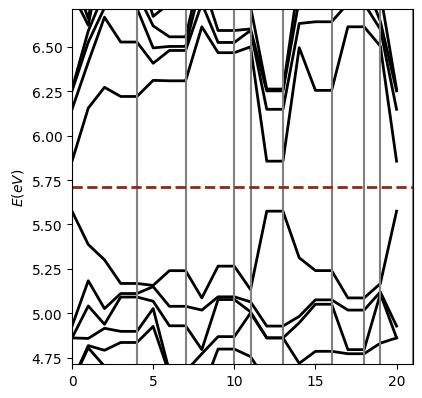

In [41]:
plt.plot(evals, 'k',linewidth=2)

#make orbital resolved bandstructure ()
#make site-resolved bandstructure??()

k_index = np.arange(0,np.shape(evals)[0])

plt.xlim(klabels[0],klabels[-1])
plt.ylabel(r'$E (eV)$')
for k in klabels:
    plt.axvline(k,color="grey")
plt.axhline(mu,linestyle="dashed",color="#852D1F",linewidth=2)
plt.tight_layout()
plt.ylim(mu-1,mu+1)
plt.gcf().set_size_inches(4, 4)

#plt.savefig(wann_dir+"/2x2x2_band.png",dpi=400,bbox_inches='tight')  

In [31]:
den_eig = np.zeros((len(tb.kSpan),tb.norb))
den_evec = np.zeros((len(tb.kSpan),tb.norb,tb.norb))

def solve_1pRDM(mu,occ): #this works
    en = tb.enUM[:, :, 0]
    um = tb.enUM[:, :, 1:occ+1] #only taking first 12 bands #k,orb,band
    OpRDM = np.einsum("kbc,kdc->bd",um,np.conj(um))
    return OpRDM/len(tb.kSpan)
onedmat = solve_1pRDM(mu=mu,occ=occ)


atoms = []
for n in np.arange(int(tb.norb)/4):
    atom=[int(n*4),int(n*4+1),int(n*4+2),int(n*4+3)]
    atoms.append(atom)


atomic_Density = np.zeros((len(atoms),len(atoms)))
for i,m in enumerate(atoms): 
    for l,p in enumerate(atoms):
        #atomic_Wiberg[i,l] = np.sum(np.real(Wiberg)[np.ix_(m,p)])#/len(tb.kSpan)
        atomic_Density[i,l] = np.sum(np.real(onedmat)[np.ix_(m,p)])
mulliken_charges = np.diag(atomic_Density)
Wiberg = (onedmat*onedmat.T)**2


In [58]:
tb.norb

16

In [12]:
def solve_1pRDM(mu,occ): 
    en = tb.enUM[:, :, 0]
    um = tb.enUM[:, :, 1:occ+1] #only taking occupied bands #k,orb,band (this is ok for insulator I think)
    OpRDM = np.einsum("kbc,kdc->bd",um,np.conj(um)) #summing over all k, inner product b and d orbitals for wavefunction c
    return OpRDM/len(tb.kSpan) #spin-summed
onedmat = solve_1pRDM(mu=mu,occ=occ)
atomic_Density = np.zeros((len(atoms),len(atoms)))

for i,m in enumerate(atoms): 
    for l,p in enumerate(atoms):
        atomic_Density[i,l] = np.sum(np.real(onedmat)[np.ix_(m,p)])


def solve_wiberg_test(mu,occ): 
    en = tb.enUM[:, :, 0]
    um = tb.enUM[:, :, 1:occ+1] #only taking occupied bands #k,orb,band (this is ok for insulator I think)
    print("um shape",np.shape(um))
    OpRDM = np.einsum("kbc,kdc,kdc,kbc->bd",um,np.conj(um),um,np.conj(um)) #summing over all k, inner product b and d orbitals for wavefunction c
    return OpRDM/len(tb.kSpan) #spin-summed

wiberg1 = np.abs(np.abs(onedmat)*onedmat) #spin adds factor of 2
wiberg2 = solve_wiberg_test(mu,occ)
print(np.sum(wiberg1[4:8,0:4])) #wiberg for
print(np.sum(wiberg2[4:8,0:4])) #wiberg for


um shape (1000, 32, 20)
0.006395485231877173
(0.21777433671962432+4.3475952760669037e-20j)


In [114]:
np.round(wiberg1[0,:],3)
np.sum(np.real(wiberg2[0,4:8])/np.real(onedmat[0,0]))

0.11485900021641667

In [13]:
Matrix(np.round(np.real(wiberg2),3))

Matrix([
[0.145, 0.008, 0.009, 0.003, 0.119, 0.006, 0.007, 0.004, 0.104, 0.005, 0.007, 0.004,  0.13, 0.007, 0.008, 0.003,  0.03, 0.024, 0.024, 0.019, 0.027, 0.022, 0.019, 0.027, 0.026,  0.02, 0.022, 0.024, 0.029, 0.022, 0.027, 0.016],
[0.008, 0.011, 0.007, 0.005, 0.006, 0.009, 0.006, 0.007, 0.005, 0.007, 0.005, 0.006, 0.007, 0.009, 0.006, 0.005, 0.004,  0.02, 0.014, 0.014, 0.004, 0.017, 0.011, 0.018, 0.003, 0.016, 0.013, 0.015, 0.003, 0.019, 0.016, 0.012],
[0.009, 0.007, 0.014, 0.004, 0.007, 0.006, 0.012, 0.005, 0.007, 0.005, 0.009, 0.005, 0.008, 0.006, 0.011, 0.004, 0.004, 0.014, 0.024, 0.009, 0.003, 0.012,  0.02, 0.012, 0.003, 0.012, 0.023, 0.012, 0.004, 0.014, 0.027, 0.009],
[0.003, 0.005, 0.004, 0.012, 0.004, 0.007, 0.005, 0.009, 0.004, 0.006, 0.005, 0.008, 0.003, 0.005, 0.004,  0.01, 0.003, 0.013, 0.008, 0.021, 0.005, 0.018, 0.011, 0.019, 0.005, 0.016, 0.011, 0.017, 0.003, 0.012, 0.008,  0.02],
[0.119, 0.006, 0.007, 0.004, 0.145, 0.008, 0.009, 0.003,  0.13, 0.007, 0.008, 0.003, 0.

In [34]:
print(np.diag(onedmat[:4]))
print(np.sum(np.diag(onedmat[:4])))#two electrons on the first atom

[0.68832784+0.j 0.43722405+0.j 0.43722405+0.j 0.43722405+0.j]
(2+0j)


In [68]:
print(np.sum(Matrix(np.abs(2*onedmat[4:,:4]*2*onedmat[:4,4:]))))
print(4*np.trace(onedmat[4:,:4]@onedmat[:4,4:])*2)

0.361763760495753
(0.7235275209915066+0j)


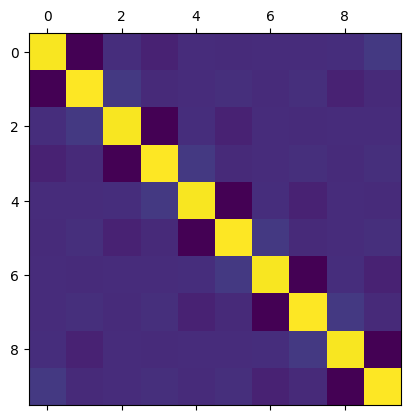

In [116]:
np.sum(np.diag(np.real(atomic_Density)))
plt.matshow(atomic_Density)
#plt.plot(np.arange(mu-2,mu+2,0.01),tb.solve_dos(muar = np.arange(mu-2,mu+2,0.01), sigma = 0.1))
#zero_arr = np.arange(mu-2,mu+2,0.01)[tb.solve_dos(muar = np.arange(mu-2,mu+2,0.01), sigma = 0.1)==0]
#bandgap = np.max(zero_arr) - np.min(zero_arr)
#print(bandgap)

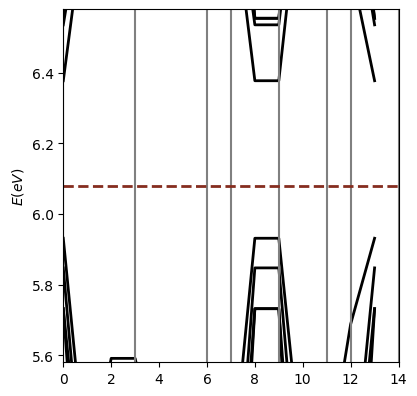

In [6]:

plt.plot(evals, 'k',linewidth=2)

#make orbital resolved bandstructure ()
#make site-resolved bandstructure??()

k_index = np.arange(0,np.shape(evals)[0])

plt.xlim(klabels[0],klabels[-1])
plt.ylabel(r'$E (eV)$')
for k in klabels:
    plt.axvline(k,color="grey")
plt.axhline(mu,linestyle="dashed",color="#852D1F",linewidth=2)
plt.tight_layout()
plt.ylim(mu-0.5,mu+0.5)
plt.gcf().set_size_inches(4, 4)

In [38]:
qgt_xx = tb.solve_QGT_kresolved(mu=mu,dkx = np.array([0,1,0])) #QGT from Nish's code

/projects/SCHOOP/gc2596/ipynb_notebooks/TBLR2.py:53: RuntimeWarning: overflow encountered in exp
  return 1.0/(1.0 + np.exp(beta*x))
/projects/SCHOOP/gc2596/ipynb_notebooks/TBLR2.py:834: RuntimeWarning: divide by zero encountered in divide
  result = np.where(np.abs(emn) < delta, 0, fnm / (emn**2))
/projects/SCHOOP/gc2596/ipynb_notebooks/TBLR2.py:834: RuntimeWarning: invalid value encountered in divide
  result = np.where(np.abs(emn) < delta, 0, fnm / (emn**2))


In [19]:
atoms = []
for n in np.arange(int(tb.norb/4)):
    atom1=[int(n*2),int(n*2+1),int(n*2+2),int(n*2+3),]
    atoms.append(atom1)
print("atoms",atoms)

atomic_metric_xx = np.zeros((len(atoms),len(atoms),len(atoms),len(atoms)))
atomic_metric_xy = np.zeros((len(atoms),len(atoms),len(atoms),len(atoms)))
atomic_metric_yy = np.zeros((len(atoms),len(atoms),len(atoms),len(atoms)))
atomic_metric_yx = np.zeros((len(atoms),len(atoms),len(atoms),len(atoms)))
for i,m in enumerate(tqdm(atoms)): 
    for j,n in enumerate(atoms):
        for k,o in enumerate(atoms):
            for l,p in enumerate(atoms):
                atomic_metric_xx[i,j,k,l] = np.sum(qgtxx[np.ix_(m,n,o,p)]) 
                atomic_metric_xy[i,j,k,l] = np.sum(qgtxy[np.ix_(m,n,o,p)]) 
                atomic_metric_yx[i,j,k,l] = np.sum(qgtyx[np.ix_(m,n,o,p)]) 
                atomic_metric_yy[i,j,k,l] = np.sum(qgtyy[np.ix_(m,n,o,p)]) 


atoms [[0, 1, 2, 3], [2, 3, 4, 5], [4, 5, 6, 7], [6, 7, 8, 9], [8, 9, 10, 11], [10, 11, 12, 13], [12, 13, 14, 15], [14, 15, 16, 17], [16, 17, 18, 19], [18, 19, 20, 21], [20, 21, 22, 23], [22, 23, 24, 25], [24, 25, 26, 27], [26, 27, 28, 29], [28, 29, 30, 31], [30, 31, 32, 33]]


  0%|          | 0/16 [00:00<?, ?it/s]/tmp/ipykernel_797795/2443323036.py:15: ComplexWarning: Casting complex values to real discards the imaginary part
  atomic_metric_xx[i,j,k,l] = np.sum(qgtxx[np.ix_(m,n,o,p)])
  0%|          | 0/16 [00:00<?, ?it/s]


TypeError: 'int' object is not subscriptable

In [17]:
#INCLUDING MORE FOR LOOPS, NOT k-resolved(took too much memory)
import opt_einsum as oe
mu=mu 
beta_const = 1.e2			# smearing for Fermi factors
dkx = np.array([1,0,0])	    # direction for taking k derivative
dky = np.array([0,1,0])
k_step = 1.e-3
FS=False
delta=1.e-3							# infinitesimal step
nkp=len(tb.kSpan)
#Jop=np.zeros((nkp,tb.norb,tb.norb)) #size K,m,n
Jop1=[]
Jop2 = []
def Fermi(beta_const, x):
	return 1.0/(1.0 + np.exp(beta_const*x))

def FNM(em, en):
    delta = 1.e-3  
    emn = em - en
    fn = Fermi(beta_const, en)
    fm = Fermi(beta_const, em)
    fnm = fn*(1.0 - fm)
    if FS:
        result = np.where(np.abs(emn) < delta, -DFermi(beta_const, em), fnm / (emn**2))
    else:
        result = np.where(np.abs(emn) < delta, 0.0, fnm / (emn**2))
    return result

# Precompute 'em' and 'en' since they do not depend on 'time'
def calc_QM():
    em = tb.enUM[:, :, 0] - mu
    en = tb.enUM[:, :, 0] - mu
    em = em[:, :, np.newaxis]  # Shape (num_i, norb, 1)
    en = en[:, np.newaxis, :]  # Shape (num_i, 1, norb)
    
    pref = FNM(en, em)  # vectorized FNM
    qgtxx=0
    qgtxy=0
    qgtyx=0
    qgtyy=0
    		# Reshape for broadcasting to compute differences
    em = em[:, :, np.newaxis]  # Shape (num_i, norb, 1)
    en = en[:, np.newaxis, :]  # Shape (num_i, 1, norb)
    
    qgtxx=0
    
    for i,k in enumerate( tqdm(tb.kSpan )):
        Hk = tb.ham(k)
        um = tb.enUM[i,:,1:]
        Hk_dkx = tb.ham(k + k_step*dkx)
        Hk_dky = tb.ham(k + k_step*dky)
        dHx = (Hk_dkx - Hk)/k_step
        dHy = (Hk_dky - Hk)/k_step
        um = np.asmatrix(um)
        uH = um.H
        Jv1x = oe.contract("ia,ad,dj->adij",uH,dHx,um)
        Jv2x = oe.contract("ic,cb,bj->bcij",uH,dHx,um)
        Jv1y = oe.contract("ia,ad,dj->adij",uH,dHy,um)
        Jv2y = oe.contract("ic,cb,bj->bcij",uH,dHy,um)
        Jv2x_conj = np.conj(Jv2x)
        Jv2y_conj = np.conj(Jv2y)
        qgtxx += oe.contract("ij,adij,bcij->abcd",pref[i],Jv1x,Jv2x_conj)
        qgtxy += oe.contract("ij,adij,bcij->abcd",pref[i],Jv1x,Jv2y_conj)
        qgtyx += oe.contract("ij,adij,bcij->abcd",pref[i],Jv1y,Jv2x_conj)
        qgtyy += oe.contract("ij,adij,bcij->abcd",pref[i],Jv1y,Jv2y_conj)
    return qgtxx,qgtxy,qgtyx,qgtyy


In [ ]:
denom = (len(tb.kSpan)*occ)
qgtxx,qgtxy,qgtyx,qgtyy = calc_QM()
np.save(wann_dir+'QM_orb_res_qgtxx.npy', qgtxx/denom)
np.save(wann_dir+'QM_orb_res_qgtyy.npy', qgtyy/denom)
np.save(wann_dir+'QM_orb_res_qgtxy.npy', qgtxy/denom)
np.save(wann_dir+'QM_orb_res_qgtyx.npy', qgtxx/denom)

/tmp/ipykernel_1811849/937480623.py:26: RuntimeWarning: divide by zero encountered in divide
  result = np.where(np.abs(emn) < delta, 0.0, fnm / (emn**2))
/tmp/ipykernel_1811849/937480623.py:26: RuntimeWarning: invalid value encountered in divide
  result = np.where(np.abs(emn) < delta, 0.0, fnm / (emn**2))
  0%|          | 0/1000 [00:00<?, ?it/s]

In [40]:
qgtxx=np.load(wann_dir+'/QM_orb_res_qgtxx.npy')
qgtyy=np.load(wann_dir+'/QM_orb_res_qgtyy.npy')
qgtxy=np.load(wann_dir+'/QM_orb_res_qgtxy.npy')
qgtyx=np.load(wann_dir+'/QM_orb_res_qgtyx.npy')

In [14]:
qgtxx=qgtxx/(len(tb.kSpan)*occ)
qgtxy=qgtxy/(len(tb.kSpan)*occ)
qgtyx=qgtyx/(len(tb.kSpan)*occ)
qgtyy=qgtyy/(len(tb.kSpan)*occ)

In [41]:
print(np.shape(qgtxx))
atoms = []
for n in np.arange(int(tb.norb)/4):
    atom=[int(n*4),int(n*4+1),int(n*4+2),int(n*4+3)]
    atoms.append(atom)

atomic_metric = np.zeros((len(atoms),len(atoms),len(atoms),len(atoms)))
for i,m in enumerate(atoms): 
    for j,n in enumerate(atoms):
        for k,o in enumerate(atoms):
            for l,p in enumerate(atoms):
                atomic_metric[i,j,k,l] = np.sum(qgtxx[np.ix_(m,n,o,p)]+qgtyy[np.ix_(m,n,o,p)]) 



(64, 64, 64, 64)


/tmp/ipykernel_1138299/3333148307.py:12: ComplexWarning: Casting complex values to real discards the imaginary part
  atomic_metric[i,j,k,l] = np.sum(qgtxx[np.ix_(m,n,o,p)]+qgtyy[np.ix_(m,n,o,p)])


In [9]:


#0 is connected to 1,3,5,9
#If it starts at 0 and goes to 1, often stay at 1 or shift back to 0
import itertools

def canonicalize(combo):
    mapping = {}
    next_label = ord('a')
    result = []
    for x in combo:
        if x not in mapping:
            mapping[x] = chr(next_label)
            next_label += 1
        result.append(mapping[x])
    return ''.join(result)
import itertools

def find_combo_list(orb_list, num_un):
    patterns = set()
    for combo in itertools.product(orb_list, repeat=4):
        if len(set(combo)) >= num_un:
            patterns.add(canonicalize(combo))

    return sorted(patterns)
    
def find_atom_metric(atomic_metric,num_un):
    atomic_metric_ab = atomic_metric.copy()
    for a in range(len(atoms)):
        for b in range(len(atoms)): 
            for c in range(len(atoms)):
                indices = [a,b,c][:num_un]
                #print("indices",indices)
                direct_indices = np.asarray(list(itertools.product(indices,repeat=4)))
                for ind in direct_indices:
                    atomic_metric_ab[ind[0],ind[1],ind[2],ind[3]] = 0
    return atomic_metric_ab

combo_a = find_combo_list(["a"],1)
combo_ab = find_combo_list(["a","b"],2)
combo_abc = find_combo_list(["a","b","c"],3)
combo_abcd = find_combo_list(["a","b","c","d"],4)


atoms = []
for n in np.arange(int(tb.norb)/4):
    atom=[int(n*4),int(n*4+1),int(n*4+2),int(n*4+3)]
    atoms.append(atom)

atomic_metric = np.zeros((len(atoms),len(atoms),len(atoms),len(atoms)))
for i,m in enumerate(atoms): 
    for j,n in enumerate(atoms):
        for k,o in enumerate(atoms):
            for l,p in enumerate(atoms):
                atomic_metric[i,j,k,l] = np.sum(qgtxx[np.ix_(m,n,o,p)]+qgtyy[np.ix_(m,n,o,p)])  #took out qgtyy to make it faster calc
                

atom_metric_a = find_atom_metric(atomic_metric,0)
atom_metric_ab = find_atom_metric(atomic_metric,1)
atom_metric_abc = find_atom_metric(atomic_metric,2)
atom_metric_abcd = find_atom_metric(atomic_metric,3)

data1 = []
data2 = []
data3 = []
data4 = []
#Find quantum metric one orbitals
denom=1
for combo in combo_a:
    data1.append([str(combo),np.float64(np.sum(np.einsum(combo+"->",atomic_metric))/denom)])

#Find quantum metric two orbitals                
for combo in np.setdiff1d(combo_ab,combo_a):
    data2.append([str(combo),np.float64(np.sum(np.einsum(combo+"->",atom_metric_ab))/denom)])
#Find quantum metric three orbitals
for combo in np.setdiff1d(combo_abc,combo_ab):
    data3.append([str(combo),np.float64(np.sum(np.einsum(combo+"->",atom_metric_abc))/denom)])
#Find quantum metric four orbitals:
for combo in np.setdiff1d(combo_abcd,combo_abc):
    data4.append([str(combo),np.float64(np.sum(np.einsum(combo+"->",atom_metric_abcd))/denom)])

#Find Quantum Metric four  orbitals
data1=np.array(data1)
data2=np.array(data2)
data3=np.array(data3)
data4=np.array(data4)
print(np.sum(qgtxx+qgtyy)/denom)



(36, 36, 36, 36)


/tmp/ipykernel_1138299/2251608216.py:12: ComplexWarning: Casting complex values to real discards the imaginary part
  atomic_metric[i,j,k,l] = np.sum(qgtxx[np.ix_(m,n,o,p)]+qgtyy[np.ix_(m,n,o,p)])


(16, 16, 16, 16)
(3360,)
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
2

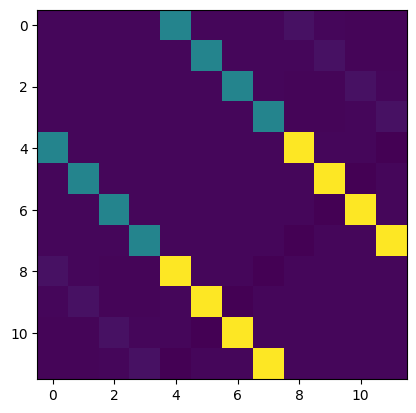

In [42]:
#13,9,5
print(np.shape(atomic_metric))
plt.imshow(direct_sum)
a_list=[]
b_list=[]
c_list=[]
abbc_list=[]
for a in np.arange(len(atoms)):
    for b in np.arange(len(atoms)):
        for c in np.arange(len(atoms)):
            if a !=b and a!=c and c!=b: 
                a_list.append(a)
                b_list.append(b)
                c_list.append(c)
                abbc_list.append(atomic_metric[a,b,c,b])
abbc_idx = np.argsort(abbc_list)[::-1]
#make abbc list
#are they equal list? 
np.array(a_list)[abbc_idx]
np.array(b_list)[abbc_idx]
np.array(c_list)[abbc_idx]

print(np.shape(np.array(abbc_list)[abbc_idx]))
data= {"a" : np.array(a_list)[abbc_idx],
     "b" : np.array(b_list)[abbc_idx],
     "c" : np.array(c_list)[abbc_idx],
     "abbc":np.array(abbc_list)[abbc_idx]}
df = pd.DataFrame(data)
df.to_csv(wann_dir+"/abbc_components.csv")
for x in range(len(c_list)):
    print(x)


(16, 16, 16, 16)
(240,)


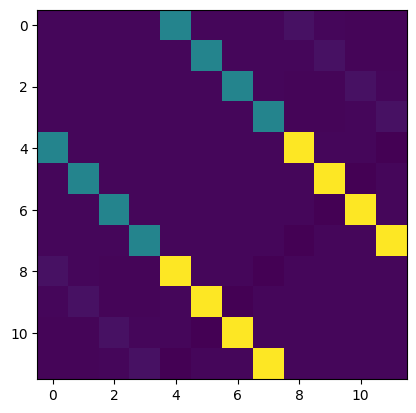

In [43]:
#make abba list
print(np.shape(atomic_metric))
plt.imshow(direct_sum)
a_list=[]
b_list=[]
c_list=[]
abba_list=[]
for a in np.arange(len(atoms)):
    for b in np.arange(len(atoms)):
        if a !=b :
            a_list.append(a)
            b_list.append(b)
            abba_list.append(atomic_metric[a,b,a,b])
abba_idx = np.argsort(abba_list)[::-1]

#are they equal list? 
np.array(a_list)[abba_idx]
np.array(b_list)[abba_idx]

print(np.shape(np.array(abba_list)[abba_idx]))
data= {"a" : np.array(a_list)[abba_idx],
     "b" : np.array(b_list)[abba_idx],
     "abba":np.array(abba_list)[abba_idx]}
df = pd.DataFrame(data)
df.to_csv(wann_dir+"/abba_components.csv")
for x in range(len(c_list)):
    print(x)

(16, 16, 16, 16)
(240,)


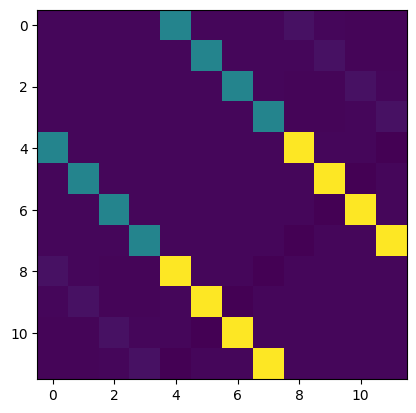

In [44]:
#make abab list
print(np.shape(atomic_metric))
plt.imshow(direct_sum)
a_list=[]
b_list=[]
c_list=[]
abab_list=[]
for a in np.arange(len(atoms)):
    for b in np.arange(len(atoms)):
        if a !=b :
            a_list.append(a)
            b_list.append(b)
            abab_list.append(atomic_metric[a,a,b,b])
abab_idx = np.argsort(abab_list)[::-1]

#are they equal list? 
np.array(a_list)[abab_idx]
np.array(b_list)[abab_idx]

print(np.shape(np.array(abab_list)[abab_idx]))
data= {"a" : np.array(a_list)[abab_idx],
     "b" : np.array(b_list)[abab_idx],
     "abba":np.array(abab_list)[abab_idx]}
df = pd.DataFrame(data)
df.to_csv(wann_dir+"/abab_components.csv")
for x in range(len(c_list)):
    print(x)

(16, 16, 16, 16)
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
2

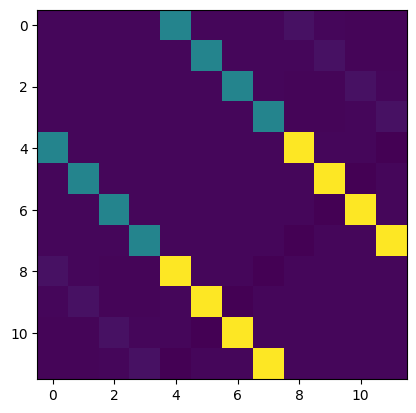

In [45]:
#make abcd list
print(np.shape(atomic_metric))
plt.imshow(direct_sum)
a_list=[]
b_list=[]
c_list=[]
d_list=[]
abcd_list=[]
for a in np.arange(len(atoms)):
    for b in np.arange(len(atoms)):
        for c in np.arange(len(atoms)):
            for d in np.arange(len(atoms)):
                if a !=b and a !=c and a !=d and b !=c and b !=d and c !=d:
                    a_list.append(a)
                    b_list.append(b)
                    c_list.append(c)
                    d_list.append(d)
                    abcd_list.append(atomic_metric[a,c,d,b])
abcd_idx = np.argsort(abcd_list)[::-1]

data= {
     "a" : np.array(a_list)[abcd_idx],
     "b" : np.array(b_list)[abcd_idx],
     "c" : np.array(c_list)[abcd_idx],
     "d" : np.array(d_list)[abcd_idx],
     "abcd":np.array(abcd_list)[abcd_idx]}
df = pd.DataFrame(data)
df.to_csv(wann_dir+"/abcd_components.csv")
for x in range(len(c_list)):
    print(x)

(16, 16, 16, 16)
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
2

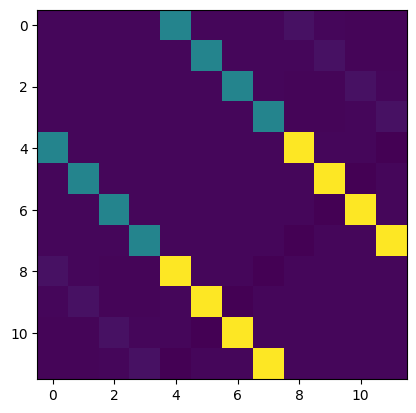

In [47]:
#make acba list
print(np.shape(atomic_metric))
plt.imshow(direct_sum)
a_list=[]
b_list=[]
c_list=[]
d_list=[]
acba_list=[]
for a in np.arange(len(atoms)):
    for b in np.arange(len(atoms)):
        for c in np.arange(len(atoms)):
                if a !=b and a !=c and b !=c :
                    a_list.append(a)
                    b_list.append(b)
                    c_list.append(c)
                    d_list.append(d)
                    acba_list.append(atomic_metric[a,b,a,c])
acba_idx = np.argsort(acba_list)[::-1]

data= {
     "a" : np.array(a_list)[acba_idx],
     "b" : np.array(b_list)[acba_idx],
     "c" : np.array(c_list)[acba_idx],
     "acba":np.array(acba_list)[acba_idx]}
df = pd.DataFrame(data)
df.to_csv(wann_dir+"/acba_components.csv")
for x in range(len(c_list)):
    print(x)

In [10]:
#For BaTiO3
#atoms = []
#for n in np.arange(int(tb.norb)/20):
#    atom1=[int(n*20),int(n*20+1),int(n*20+2),int(n*20+3),int(n*20+4),int(n*20+5)]
#    atom2=[int(n*20+6),int(n*20+7),int(n*20+8),int(n*20+9),int(n*20+10)]
#    atom3=[int(n*20+11),int(n*20+12),int(n*20+13),int(n*20+14),int(n*20+15),int(n*20+16),int(n*20+17),int(n*20+18),int(n*20+19)]
#    atoms.append(atom1)
#    atoms.append(atom2)
#    atoms.append(atom3)
#For GeTe,AlP
atoms = []
for n in np.arange(int(tb.norb)/4):
    atom=[int(n*4),int(n*4+1),int(n*4+2),int(n*4+3)]
    atoms.append(atom)
#for NaCl
#atoms = []
#for n in np.arange(int(tb.norb)/7):
#    atom1=[int(n*7),int(n*7+1),int(n*7+2),int(n*7+3)]
#    atom2=[int(n*7+4),int(n*7+5),int(n*7+6)]
#    atoms.append(atom1)
#    atoms.append(atom2)
#print("atoms",atoms)

##for PbS
#atoms = []
#for n in np.arange(int(tb.norb)/3):
#    atom1=[int(n*3),int(n*3+1),int(n*3+2)]
#    atoms.append(atom1)
print("atoms",atoms)

atomic_metric = np.zeros((len(atoms),len(atoms),len(atoms),len(atoms)))
for i,m in enumerate(atoms): 
    for j,n in enumerate(atoms):
        for k,o in enumerate(atoms):
            for l,p in enumerate(atoms):
                atomic_metric[i,j,k,l] = np.sum(qgtxx[np.ix_(m,n,o,p)]+qgtyy[np.ix_(m,n,o,p)]) 

atoms [[0, 1, 2, 3], [4, 5, 6, 7], [8, 9, 10, 11], [12, 13, 14, 15], [16, 17, 18, 19], [20, 21, 22, 23], [24, 25, 26, 27], [28, 29, 30, 31], [32, 33, 34, 35], [36, 37, 38, 39], [40, 41, 42, 43], [44, 45, 46, 47], [48, 49, 50, 51], [52, 53, 54, 55], [56, 57, 58, 59], [60, 61, 62, 63]]


/tmp/ipykernel_826258/561302436.py:36: ComplexWarning: Casting complex values to real discards the imaginary part
  atomic_metric[i,j,k,l] = np.sum(qgtxx[np.ix_(m,n,o,p)]+qgtyy[np.ix_(m,n,o,p)])


In [81]:

import itertools
denom = (len(tb.kSpan)*8*4)
combo_ar = np.asarray(list(itertools.product(["a","c","d","b"],repeat=4)))
combo_list = [combo[0]+combo[1]+combo[2]+combo[3] for combo in combo_ar]
combo_list = np.unique(combo_list)
#print(combo_list[np.sum(np.einsum(combo+"->",atomic_metric))/denom!=0])
for combo in combo_list:
    if np.sum(np.einsum(combo+"->",atomic_metric))/denom!=0:
        #print(combo)
        print(np.sum(np.einsum(combo+"->",atomic_metric))/denom)
    #print(combo[0]+combo[3]+combo[1]+combo[2])
    #print(sum)


0.004231051803790976
0.004231051803790976
0.004231051803790976
0.004231051803790976
0.004231051803790976
0.004231051803790976
0.004231051803790976
0.004231051803790976
0.004231051803790976
0.004231051803790976
0.004231051803790976
0.004231051803790976
0.004231051803790976
0.004231051803790976
0.004231051803790976
0.004231051803790976
0.004231051803790976
0.004231051803790976
0.004231051803790976
0.004231051803790976
0.004231051803790976
0.004231051803790976
0.004231051803790976
0.004231051803790976


In [72]:
np.sum(np.einsum("abcd"+"->",atomic_metric))/denom

2.1843125663737775

In [10]:
motif_direct_xx =   np.einsum("ijij->ij",(atomic_metric))
motif_indirect_xx =   np.einsum("iabj->ij",(atomic_metric))

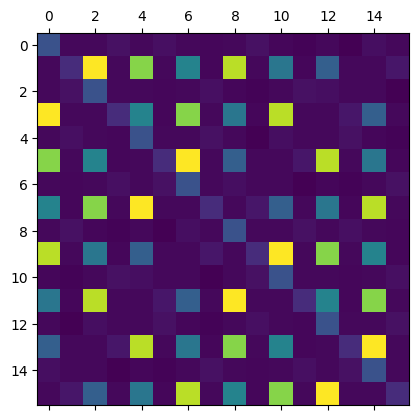

In [40]:
plt.matshow(motif_indirect_xx )

In [78]:
1-np.sum(np.abs(np.real(motif_direct_xx)-np.real(motif_direct_xx).T))/(2*np.sum(np.real(motif_direct_xx)))

0.35478462446932035

In [50]:
np.sum(np.abs(np.real(motif_direct_xx)-np.real(motif_direct_xx).T))/(2*np.sum(np.real(motif_direct_xx)))

0.9659161650559563

In [6]:

def ham_func(k):
    kx=k[0]
    ky=k[1]
    H_res = np.zeros((n_orb,n_orb),dtype = complex)
    for i in np.arange(0,n_orb,1):
        for j in np.arange(0,n_orb):
            if len(H_mod[i][j]) == 0:
                pass 
            else:
                for item in H_mod[i][j]:
                    item0=complex(item[0])
                    item1=complex(item[1])
                    item2=complex(item[2])
                    H_res[i][j] += np.round(item0,10)*(np.exp(1j* kx *item1+1j* ky *item2 ))     
    return H_res

In [8]:
ham_func([0,0,0])

NameError: name 'n_orb' is not defined

In [207]:
my_model._lat

array([[0.       , 1.7803726, 1.7803726],
       [1.7803726, 0.       , 1.7803726],
       [1.7803726, 1.7803726, 0.       ]])

In [206]:
my_model._orb[i]

array([-0.25, -0.25, -0.25])

In [204]:
my_model._orb[i]@my_model._lat

array([-0.8901863, -0.8901863, -0.8901863])

/home/gc2596/anaconda3/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/gc2596/anaconda3/lib/python3.11/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


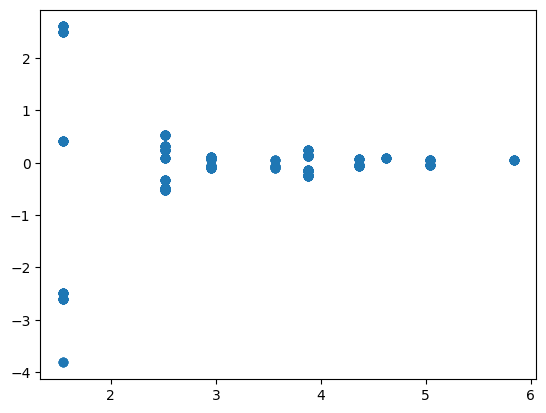

In [198]:
plt.scatter(abs_dist_list,t_list)

In [76]:
Matrix(np.round(my_model.k_uniform_mesh([10,10,10])-0.5-tb.kSpan,5))

Matrix([
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[0, 0, 0],
[

In [81]:
my_model._orb[i]-my_model._orb[j]@

array([0.25, 0.25, 0.25])

In [196]:
my_model._lat

array([[0.       , 1.7803726, 1.7803726],
       [1.7803726, 0.       , 1.7803726],
       [1.7803726, 1.7803726, 0.       ]])

In [94]:
my_model._sol_ham(my_model._gen_ham([0,0,0]))

array([-11.685242,   9.990353,   9.990353,   9.990353,  15.552489,
        15.552489,  15.552489,  23.486318])

In [4]:
dir(my_model)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_assume_position_operator_diagonal',
 '_dim_k',
 '_dim_r',
 '_gen_ham',
 '_hoppings',
 '_lat',
 '_norb',
 '_nspin',
 '_nsta',
 '_orb',
 '_per',
 '_shift_to_home',
 '_site_energies',
 '_site_energies_specified',
 '_sol_ham',
 '_val_to_block',
 'change_nonperiodic_vector',
 'cut_piece',
 'display',
 'get_lat',
 'get_num_orbitals',
 'get_orb',
 'ignore_position_operator_offdiagonal',
 'k_path',
 'k_uniform_mesh',
 'make_supercell',
 'position_expectation',
 'position_hwf',
 'position_matrix',
 'reduce_dim',
 'remove_orb',
 'set_hop',
 'set_onsite',
 'solve_all',
 'solve_one',
 'visualize']

In [49]:
Matrix(np.round(my_model._gen_ham([0,0,0])-my_model._gen_ham([3,0,0]),3))

Matrix([
[                 0,               0,               0,               0, -17.586 - 17.586*I,               0,               0,               0],
[                 0,               0,               0,               0,                  0, 2.781 + 2.781*I,               0,               0],
[                 0,               0,               0,               0,                  0,               0, 2.781 + 2.781*I,               0],
[                 0,               0,               0,               0,                  0,               0,               0, 2.781 + 2.781*I],
[-17.586 + 17.586*I,               0,               0,               0,                  0,               0,               0,               0],
[                 0, 2.781 - 2.781*I,               0,               0,                  0,               0,               0,               0],
[                 0,               0, 2.781 - 2.781*I,               0,                  0,               0,               0,  

In [55]:
eval1,evec1 = np.linalg.eigh(my_model._gen_ham([0,0,0]))
eval2,evec2 = np.linalg.eigh(my_model.make_supercell(_gen_ham([1,0,0]))
print(eval1-eval2)
print(eval2)

[ 3.55271368e-15 -5.32907052e-15 -1.77635684e-15 -3.55271368e-15
 -5.32907052e-15 -7.10542736e-15 -5.32907052e-15 -3.55271368e-15]
[-11.685242   9.990353   9.990353   9.990353  15.552489  15.552489
  15.552489  23.486318]


In [6]:
#INCLUDING MORE FOR LOOPS, NOT k-resolved(took too much memory)
mu=mu 
beta_const = 1.e2			# smearing for Fermi factors
dkx = np.array([1,0,0])				# direction for taking k derivative
dky = np.array([0,1,0])
k_step = 1.e-3
FS=False
delta=1.e-3							# infinitesimal step
nkp=len(tb.kSpan)
#Jop=np.zeros((nkp,tb.norb,tb.norb)) #size K,m,n
Jop1=[]
Jop2 = []
def Fermi(beta_const, x):
	return 1.0/(1.0 + np.exp(beta_const*x))

def FNM(em, en):
    delta = 1.e-3  
    emn = em - en
    fn = Fermi(beta_const, en)
    fm = Fermi(beta_const, em)
    fnm = fn*(1.0 - fm)
    if FS:
        result = np.where(np.abs(emn) < delta, -DFermi(beta_const, em), fnm / (emn**2))
    else:
        result = np.where(np.abs(emn) < delta, 0.0, fnm / (emn**2))
    return result

# Precompute 'em' and 'en' since they do not depend on 'time'
em = tb.enUM[:, :, 0] - mu
en = tb.enUM[:, :, 0] - mu
em = em[:, :, np.newaxis]  # Shape (num_i, norb, 1)
en = en[:, np.newaxis, :]  # Shape (num_i, 1, norb)

pref = FNM(en, em)  # vectorized FNM
qgtxx=0
qgtxy=0
qgtyx=0
qgtyy=0
		# Reshape for broadcasting to compute differences
em = em[:, :, np.newaxis]  # Shape (num_i, norb, 1)
en = en[:, np.newaxis, :]  # Shape (num_i, 1, norb)

qgtxx=0

def compute_qgt_k(i, k):
    Hk = tb.ham(k)
    um = tb.enUM[i, :, 1:]
    Hk_dkx = tb.ham(k + k_step * dkx)
    #Hk_dky = tb.ham(k + k_step * dky)

    dHx = (Hk_dkx - Hk) / k_step
    #dHy = (Hk_dky - Hk) / k_step

    um = np.asmatrix(um)
    uH = um.H

    Jv1x = np.einsum("ia,ad,dj->adij", uH, dHx, um)
    Jv2x = np.einsum("ic,cb,bj->bcij", uH, dHx, um)
    Jv2x_conj = np.conj(Jv2x)

    # (the simplified contraction)
    qgtxx_k = np.einsum("ij,adij,bcij->abcd", pref[i], Jv1x, Jv2x_conj)

    return qgtxx_k

def compute_qgt_direct_k(i, k):
    Hk = tb.ham(k)
    um = tb.enUM[i, :, 1:]
    Hk_dkx = tb.ham(k + k_step * dkx)
    Hk_dky = tb.ham(k + k_step * dky)

    dHx = (Hk_dkx - Hk) / k_step
    dHy = (Hk_dky - Hk) / k_step

    um = np.asmatrix(um)
    uH = um.H
    Jv1y = np.einsum("ia,ad,dj->adij",uH,dHy,um)
    # (the simplified contraction)
    qgtxx_k = np.einsum("ij,adij,bcij->abcd", pref[i], Jv1x, np.conj(Jv1x))

    return qgtxx_k

from joblib import Parallel, delayed
from tqdm import tqdm

from functools import reduce
import operator

results_1 = Parallel(n_jobs=-1, backend="loky")(
    delayed(compute_qgt_k)(i, k)
    for i, k in enumerate(tqdm(tb.kSpan))
)

/tmp/ipykernel_2909257/3247790134.py:14: RuntimeWarning: overflow encountered in exp
  return 1.0/(1.0 + np.exp(beta_const*x))
/tmp/ipykernel_2909257/3247790134.py:25: RuntimeWarning: divide by zero encountered in divide
  result = np.where(np.abs(emn) < delta, 0.0, fnm / (emn**2))
/tmp/ipykernel_2909257/3247790134.py:25: RuntimeWarning: invalid value encountered in divide
  result = np.where(np.abs(emn) < delta, 0.0, fnm / (emn**2))

100%|██████████| 200/200 [00:03<00:00, 61.95it/s]


In [14]:
qgt_xx_test = np.sum(results_1,axis=0)/(len(tb.kSpan)*4)

In [8]:
 np.sum(results_1)/(len(tb.kSpan)*4)

(2.569661895322958+5.96013039269594e-18j)

In [12]:
import itertools
for a in np.arange(tb.norb):
    for b in np.arange(tb.norb): 
        indices = [a,b]
        direct_indices = np.asarray(list(itertools.product(indices,repeat=4)))
        for ind in direct_indices:
            qgt_xx_test[ind[0],ind[1],ind[2],ind[3]] = 0

In [13]:
np.sum(qgt_xx_test)

(1.0947048868849993+7.15573433840433e-18j)

In [19]:
gxx = tb.solve_QGT_kresolved(mu=mu,dkx = np.array([0,1,0]))

In [20]:
np.sum(gxx)/(len(tb.kSpan)*4)

(2.5344828625638915+1.206723214686807e-18j)

In [56]:
def solve_1pRDM_kresolved(mu):
    OpRDM = np.zeros([len(tb.kSpan), tb.norb, tb.norb], dtype=complex)		
    for i, k in enumerate(tb.kSpan):
        en = tb.enUM[i, :, 0]
        um = tb.enUM[i, :, 1:]  # shape: (norb, norb) #order is k,orb,band
        for band in np.arange(tb.norb):
            enband = en[band]
            if enband < mu:
                bandWF = um[:,band][:,np.newaxis]#um[:, band].reshape(-1, 1)  # ensure column vector
                OpRDM[i, :, :] += bandWF @ bandWF.conj().T
            
    return OpRDM

=9.799447500000007
diag (3.999999999999999+0j)


Text(0.5, 1.0, 'Density Mat Threefold')

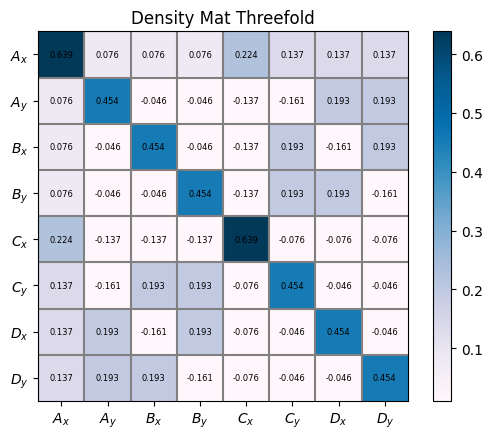

In [57]:

print(f"={mu}")
OpRDM = solve_1pRDM_kresolved(mu=mu)
onedmat = np.sum(OpRDM, axis=0)/np.size(tb.kSpan[:,0])
print("diag",np.sum(np.diag(onedmat)))
norm = mpl.colors.Normalize(vmin=0.01, vmax=np.max(np.real(onedmat)))
#norm = mpl.colors.Normalize(vmin=0.6, vmax=0.8)

im = plt.imshow(np.real(onedmat),norm=norm,cmap="PuBu")
plt.xticks( np.arange(0, tb.norb), 
           [r'$A_{x  }$', r'$A_{y  }$', r'$B_{x  }$', r'$B_{y  }$',r'$C_{x  }$', r'$C_{y  }$',r'$D_{x  }$', r'$D_{y  }$',r'$E_{x  }$', r'$E_{y  }$',r'$F_{x  }$', r'$F_{y  }$',r'$G_{x  }$', r'$G_{y  }$',r'$H_{x  }$', r'$H_{y  }$',r'$I_{x  }$', r'$I_{y  }$',r'$J_{x  }$', r'$J_{y  }$',r'$K_{x  }$', r'$K_{y  }$',r'$L_{x  }$', r'$L_{y  }$',r'$M_{x  }$', r'$M_{y  }$',r'$N_{x  }$', r'$N_{y  }$',r'$O_{x  }$', r'$O_{y  }$',r'$P_{x  }$', r'$P_{y  }$',r'$Q_{x  }$', r'$Q_{y  }$',r'$R_{x  }$', r'$R_{y  }$' ][:tb.norb] )
plt.yticks( np.arange(0, tb.norb), 
           [r'$A_{x  }$', r'$A_{y  }$', r'$B_{x  }$', r'$B_{y  }$',r'$C_{x  }$', r'$C_{y  }$',r'$D_{x  }$', r'$D_{y  }$',r'$E_{x  }$', r'$E_{y  }$',r'$F_{x  }$', r'$F_{y  }$',r'$G_{x  }$', r'$G_{y  }$',r'$H_{x  }$', r'$H_{y  }$',r'$I_{x  }$', r'$I_{y  }$',r'$J_{x  }$', r'$J_{y  }$',r'$K_{x  }$', r'$K_{y  }$',r'$L_{x  }$', r'$L_{y  }$',r'$M_{x  }$', r'$M_{y  }$',r'$N_{x  }$', r'$N_{y  }$',r'$O_{x  }$', r'$O_{y  }$',r'$P_{x  }$', r'$P_{y  }$',r'$Q_{x  }$', r'$Q_{y  }$',r'$R_{x  }$', r'$R_{y  }$' ][:tb.norb] )
for n in np.arange(0,tb.norb):
    plt.axhline(n-0.5,color="grey")
    plt.axvline(n-0.5,color="grey")
for n in np.arange(0,tb.norb):
    for m in np.arange(0,tb.norb):
        number = np.round(np.real(onedmat)[n,m],3)
        plt.text(m, n, number, va='center', ha='center',fontsize=6)
cbar = plt.colorbar(im)
plt.title(r"Density Mat Threefold")
#plt.savefig("/Users/gcarrel/Documents/SCHOOP/Distorted_Square_Net/_images/Fivefold_onsite.png",dpi=300)

#np.fill_diagonal(onedmat,0)

In [58]:
np.shape(solve_1pRDM_kresolved(mu=mu))

(1, 8, 8)

In [59]:
den_val,den_vec = np.linalg.eigh(onedmat)

In [61]:
np.shape(den_vec)

(8, 8)

In [62]:
den_val

array([-1.65687753e-16, -1.18461365e-16,  3.33589048e-17,  1.68810977e-16,
        1.00000000e+00,  1.00000000e+00,  1.00000000e+00,  1.00000000e+00])

In [63]:
#density diagonalized!! INCLUDING MORE FOR LOOPS, NOT k-resolved(took too much memory)
mu=mu 
beta_const = 1.e2			# smearing for Fermi factors
dkx = np.array([1,0,0])				# direction for taking k derivative
dky = np.array([0,1,0])
k_step = 1.e-3
FS=False
delta=1.e-3							# infinitesimal step
nkp=len(tb.kSpan)
#Jop=np.zeros((nkp,tb.norb,tb.norb)) #size K,m,n
Jop1=[]
Jop2 = []
def Fermi(beta_const, x):
	return 1.0/(1.0 + np.exp(beta_const*x))

def FNM(em, en):
    delta = 1.e-3  
    emn = em - en
    fn = Fermi(beta_const, en)
    fm = Fermi(beta_const, em)
    fnm = fn*(1.0 - fm)
    if FS:
        result = np.where(np.abs(emn) < delta, -DFermi(beta_const, em), fnm / (emn**2))
    else:
        result = np.where(np.abs(emn) < delta, 0.0, fnm / (emn**2))
    return result

# Precompute 'em' and 'en' since they do not depend on 'time'
em = tb.enUM[:, :, 0] - mu
en = tb.enUM[:, :, 0] - mu
em = em[:, :, np.newaxis]  # Shape (num_i, norb, 1)
en = en[:, np.newaxis, :]  # Shape (num_i, 1, norb)

pref = FNM(en, em)  # vectorized FNM
qgtxx=0
qgtxy=0
qgtyx=0
qgtyy=0
		# Reshape for broadcasting to compute differences
em = em[:, :, np.newaxis]  # Shape (num_i, norb, 1)
en = en[:, np.newaxis, :]  # Shape (num_i, 1, norb)

qgtxx=0

inv_den_vec = np.linalg.inv(den_vec)

for i,k in enumerate( tqdm(tb.kSpan )):
    Hk = tb.ham(k)
    um = tb.enUM[i,:,1:]
    Hk_dkx = tb.ham(k + k_step*dkx)
    Hk_dky = tb.ham(k + k_step*dky)
    dHx = (Hk_dkx - Hk)/k_step
    dHy = (Hk_dky - Hk)/k_step
    um = np.asmatrix(um)
    uH = um.H

   # Jv1x = np.einsum("ia,bc,ad,dj->abcdij",uH,np.ones((tb.norb,tb.norb)),dHx,um)#*np.conj(uH @ c_mat @ dHx @b_mat@ um)
   # Jv2x = np.einsum("ic,ad,cb,bj->abcdij",uH,np.ones((tb.norb,tb.norb)),dHx,um)
    Jv1x = np.einsum("ia,ad,dj->adij",uH@den_vec,inv_den_vec@dHx@den_vec,inv_den_vec@um)#*np.conj(uH @ c_mat @ dHx @b_mat@ um)
    Jv2x = np.einsum("ic,cb,bj->bcij",uH@den_vec,inv_den_vec@dHx@den_vec,inv_den_vec@um)
    Jv1x = Jv1x[:,np.newaxis,np.newaxis,:,:,:]
    Jv2x = Jv2x[np.newaxis,:,:,np.newaxis,:,:]
    Jv2x_conj = np.conj(Jv2x)
    #jxx = np.einsum("adij,bcij->abcdij",Jv1x,Jv2x)
    #Jv1y = np.einsum("ia,ad,dj->adij",uH,dHy,um)#*np.conj(uH @ c_mat @ dHy @b_mat@ um)
    #Jv2y = np.einsum("ic,cb,bj->bcij",uH,dHy,um)
#    Jv1y = Jv1y[:,np.newaxis,np.newaxis,:,:,:]
    #Jv2y = Jv2y[np.newaxis,:,:,np.newaxis,:,:]
    #um[orbital, band]
    #Jv1x = np.einsum("ia,ad,dj->uH @ a_mat @ dHx @d_mat@ um
    jxx = np.multiply(Jv1x,Jv2x_conj)# this is taking the longest
    #jxy = Jv1x*np.conj(Jv2y)
    #jyx = Jv1y*np.conj(Jv2x)
    #jyy = Jv1y*np.conj(Jv2y)
    #this one works
    qgtxx += np.einsum("ij,abcdij->abcd", pref[i], jxx)
    #qgtxy += np.einsum("ij,abcdij->abcd", pref[i], jxy)
    #qgtyx += np.einsum("ij,abcdij->abcd", pref[i], jyx)
    #qgtyy += np.einsum("ij,abcdij->abcd", pref[i], jyy)
   

/tmp/ipykernel_1285750/1267206485.py:14: RuntimeWarning: overflow encountered in exp
  return 1.0/(1.0 + np.exp(beta_const*x))
/tmp/ipykernel_1285750/1267206485.py:25: RuntimeWarning: invalid value encountered in divide
  result = np.where(np.abs(emn) < delta, 0.0, fnm / (emn**2))
100%|██████████| 1/1 [00:00<00:00, 32.17it/s]


In [16]:
#density diagonalized!! INCLUDING MORE FOR LOOPS, NOT k-resolved(took too much memory)
mu=mu 
beta_const = 1.e2			# smearing for Fermi factors
dkx = np.array([1,0,0])				# direction for taking k derivative
dky = np.array([0,1,0])
k_step = 1.e-3
FS=False
delta=1.e-3							# infinitesimal step
nkp=len(tb.kSpan)
#Jop=np.zeros((nkp,tb.norb,tb.norb)) #size K,m,n
Jop1=[]
Jop2 = []
def Fermi(beta_const, x):
	return 1.0/(1.0 + np.exp(beta_const*x))

def FNM(em, en):
    delta = 1.e-3  
    emn = em - en
    fn = Fermi(beta_const, en)
    fm = Fermi(beta_const, em)
    fnm = fn*(1.0 - fm)
    if FS:
        result = np.where(np.abs(emn) < delta, -DFermi(beta_const, em), fnm / (emn**2))
    else:
        result = np.where(np.abs(emn) < delta, 0.0, fnm / (emn**2))
    return result

# Precompute 'em' and 'en' since they do not depend on 'time'
em = tb.enUM[:, :, 0] - mu
en = tb.enUM[:, :, 0] - mu
em = em[:, :, np.newaxis]  # Shape (num_i, norb, 1)
en = en[:, np.newaxis, :]  # Shape (num_i, 1, norb)

pref = FNM(en, em)  # vectorized FNM
qgtxx=0
qgtxy=0
qgtyx=0
qgtyy=0
		# Reshape for broadcasting to compute differences
em = em[:, :, np.newaxis]  # Shape (num_i, norb, 1)
en = en[:, np.newaxis, :]  # Shape (num_i, 1, norb)

inv_den_vec = np.linalg.inv(den_vec)

for i,k in enumerate( tqdm(tb.kSpan )):
    Hk = tb.ham(k)
    um = tb.enUM[i,:,1:]
    Hk_dkx = tb.ham(k + k_step*dkx)
    Hk_dky = tb.ham(k + k_step*dky)
    dHx = (Hk_dkx - Hk)/k_step
    dHy = (Hk_dky - Hk)/k_step
    um = np.asmatrix(um)
    uH = um.H

   # Jv1x = np.einsum("ia,bc,ad,dj->abcdij",uH,np.ones((tb.norb,tb.norb)),dHx,um)#*np.conj(uH @ c_mat @ dHx @b_mat@ um)
   # Jv2x = np.einsum("ic,ad,cb,bj->abcdij",uH,np.ones((tb.norb,tb.norb)),dHx,um)
    Jv1x = np.einsum("ia,ad,dj->adij",uH,dHx,um)#*np.conj(uH @ c_mat @ dHx @b_mat@ um)
    Jv2x = np.einsum("ic,cb,bj->bcij",uH,dHx,um)
    Jv1x = Jv1x[:,np.newaxis,np.newaxis,:,:,:]
    Jv2x = Jv2x[np.newaxis,:,:,np.newaxis,:,:]
    Jv2x_conj = np.conj(Jv2x)
    #jxx = np.einsum("adij,bcij->abcdij",Jv1x,Jv2x)
    #Jv1y = np.einsum("ia,ad,dj->adij",uH,dHy,um)#*np.conj(uH @ c_mat @ dHy @b_mat@ um)
    #Jv2y = np.einsum("ic,cb,bj->bcij",uH,dHy,um)
#    Jv1y = Jv1y[:,np.newaxis,np.newaxis,:,:,:]
    #Jv2y = Jv2y[np.newaxis,:,:,np.newaxis,:,:]
    #um[orbital, band]
    #Jv1x = np.einsum("ia,ad,dj->uH @ a_mat @ dHx @d_mat@ um
    jxx = np.multiply(Jv1x,Jv2x_conj)# this is taking the longest
    #jxy = Jv1x*np.conj(Jv2y)
    #jyx = Jv1y*np.conj(Jv2x)
    #jyy = Jv1y*np.conj(Jv2y)
    #this one works
    qgtxx += np.einsum("ij,abcdij->abcd", pref[i], jxx)
    #qgtxy += np.einsum("ij,abcdij->abcd", pref[i], jxy)
    #qgtyx += np.einsum("ij,abcdij->abcd", pref[i], jyx)
    #qgtyy += np.einsum("ij,abcdij->abcd", pref[i], jyy)
   

/tmp/ipykernel_1285750/1726983806.py:14: RuntimeWarning: overflow encountered in exp
  return 1.0/(1.0 + np.exp(beta_const*x))
/tmp/ipykernel_1285750/1726983806.py:25: RuntimeWarning: divide by zero encountered in divide
  result = np.where(np.abs(emn) < delta, 0.0, fnm / (emn**2))
/tmp/ipykernel_1285750/1726983806.py:25: RuntimeWarning: invalid value encountered in divide
  result = np.where(np.abs(emn) < delta, 0.0, fnm / (emn**2))
100%|██████████| 400/400 [00:11<00:00, 34.74it/s]


In [51]:
#not orbital resolved! not k-resolved.. 
mu=mu 
beta_const = 1.e2			# smearing for Fermi factors
dkx = np.array([1,0,0])				# direction for taking k derivative
dky = np.array([0,1,0])
k_step = 1.e-4
FS=False
delta=1.e-5							# infinitesimal step
nkp=len(tb.kSpan)
#Jop=np.zeros((nkp,tb.norb,tb.norb)) #size K,m,n
Jop1=[]
Jop2 = []
def Fermi(beta_const, x):
	return 1.0/(1.0 + np.exp(beta_const*x))

def FNM(em, en,delta):
    emn = em - en
    fn = Fermi(beta_const, en)
    fm = Fermi(beta_const, em)
    fnm = fn*(1.0 - fm)
    if FS:
        result = np.where(np.abs(emn) < delta, -DFermi(beta_const, em), fnm / (emn**2))
    else:
        result = np.where(np.abs(emn) < delta, 0.0, fnm / (emn**2))
    return result

em = tb.enUM[:, :, 0] - mu
en = tb.enUM[:, :, 0] - mu
em = em[:, :, np.newaxis]  # Shape (num_i, norb, 1)
en = en[:, np.newaxis, :]  # Shape (num_i, 1, norb)

pref = FNM(en, em,delta)  # vectorized FNM

qgtxx=np.zeros(len(tb.kSpan))
qgtxy=np.zeros(len(tb.kSpan))
qgtyx=np.zeros(len(tb.kSpan))
qgtyy=np.zeros(len(tb.kSpan))
for i,k in enumerate( tqdm(tb.kSpan )):
    Hk = tb.ham(k)
    um = tb.enUM[i,:,1:]
    um = np.asmatrix(um)
    uH = um.H
    Hk_dkx = tb.ham(k + k_step*dkx)
    Hk_dky = tb.ham(k + k_step*dky)
    dHx = (Hk_dkx - Hk)/k_step
    dHy = (Hk_dky - Hk)/k_step
    
    Jv1x = np.einsum("ia,ad,dj->ij",uH,dHx,um)#*np.conj(uH @ c_mat @ dHx @b_mat@ um)
    #Jv1y = np.einsum("ia,ad,dj->ij",uH,dHy,um)
    jxx = np.multiply(Jv1x,np.conj(Jv1x))
    #jxy = np.multiply(Jv1x,np.conj(Jv1y))
    #jyx = np.multiply(Jv1y,np.conj(Jv1x))
    #jyy = np.multiply(Jv1y,np.conj(Jv1y))
    qgtxx[i] = np.sum(pref[i]*jxx)
    #qgtxy[i] = np.sum(pref[i]*jxy)
    #qgtyx[i] = np.sum(pref[i]*jyx)
    #qgtyy[i] = np.sum(pref[i]*jyy)



/tmp/ipykernel_3840659/2917438368.py:14: RuntimeWarning: overflow encountered in exp
  return 1.0/(1.0 + np.exp(beta_const*x))
/tmp/ipykernel_3840659/2917438368.py:24: RuntimeWarning: divide by zero encountered in divide
  result = np.where(np.abs(emn) < delta, 0.0, fnm / (emn**2))
/tmp/ipykernel_3840659/2917438368.py:24: RuntimeWarning: invalid value encountered in divide
  result = np.where(np.abs(emn) < delta, 0.0, fnm / (emn**2))
  0%|          | 0/400 [00:00<?, ?it/s]/tmp/ipykernel_3840659/2917438368.py:54: ComplexWarning: Casting complex values to real discards the imaginary part
  qgtxx[i] = np.sum(pref[i]*jxx)
100%|██████████| 400/400 [00:18<00:00, 21.62it/s]


In [64]:
np.sum(qgtxx)/(len(tb.kSpan)*occ)

(5.5664106367466015-6.265583023765645e-17j)

In [22]:
occ

4

In [18]:
np.sum(qgtyy)/(len(tb.kSpan)*occ)

0.0

In [73]:
occ = 4
qgtxx_direct = np.zeros((tb.norb,tb.norb))
qgtxx_indirect = np.zeros((tb.norb,tb.norb))
#check if this works.. 
qgtxx_direct =   np.einsum("ijij->ij",(qgtxx/(occ*len(tb.kSpan))))
qgtxx_indirect = np.einsum("iabj->ij",(qgtxx/(occ*len(tb.kSpan))))
print("direct,indirect",np.sum(qgtxx_direct),np.sum(qgtxx_indirect))

direct,indirect (4.2309239263380105-4.503331261554104e-18j) (5.5664106367466015-4.163336342344337e-17j)


In [66]:
np.sum(qgtxx_indirect)

(5.5664106367466015-4.163336342344337e-17j)

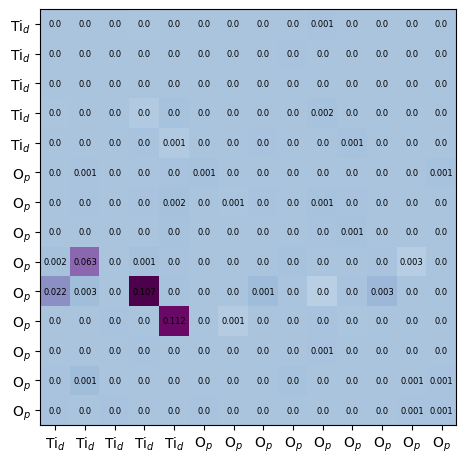

In [11]:
plt.xticks( np.arange(0, tb.norb), 
           #[r'$A_{x  }$', r'$A_{y  }$', r'$B_{x  }$', r'$B_{y  }$',r'$C_{x  }$', r'$C_{y  }$',r'$D_{x  }$', r'$D_{y  }$',r'$E_{x  }$', r'$E_{y  }$',r'$F_{x  }$', r'$F_{y  }$',r'$G_{x  }$', r'$G_{y  }$',r'$H_{x  }$', r'$H_{y  }$',r'$I_{x  }$', r'$I_{y  }$',r'$J_{x  }$', r'$J_{y  }$',r'$K_{x  }$', r'$K_{y  }$',r'$L_{x  }$', r'$L_{y  }$',r'$M_{x  }$', r'$M_{y  }$',r'$N_{x  }$', r'$N_{y  }$',r'$O_{x  }$', r'$O_{y  }$',r'$P_{x  }$', r'$P_{y  }$',r'$Q_{x  }$', r'$Q_{y  }$',r'$R_{x  }$', r'$R_{y  }$' ][:tb.norb] )
           #[r'Cl$_p$',r'Cl$_p$',r'Cl$_p$',r'Na$_s$'])
           #[r'C$_s$',r'C$_p$',r'C$_p$',r'C$_p$',r'C$_s$',r'C$_p$',r'C$_p$',r'C$_p$'])
           [r'Ti$_d$',r'Ti$_d$',r'Ti$_d$',r'Ti$_d$',r'Ti$_d$',r'O$_p$',r'O$_p$',r'O$_p$',r'O$_p$',r'O$_p$',r'O$_p$',r'O$_p$',r'O$_p$',r'O$_p$'])
plt.yticks( np.arange(0, tb.norb), 
           #[r'$A_{x  }$', r'$A_{y  }$', r'$B_{x  }$', r'$B_{y  }$',r'$C_{x  }$', r'$C_{y  }$',r'$D_{x  }$', r'$D_{y  }$',r'$E_{x  }$', r'$E_{y  }$',r'$F_{x  }$', r'$F_{y  }$',r'$G_{x  }$', r'$G_{y  }$',r'$H_{x  }$', r'$H_{y  }$',r'$I_{x  }$', r'$I_{y  }$',r'$J_{x  }$', r'$J_{y  }$',r'$K_{x  }$', r'$K_{y  }$',r'$L_{x  }$', r'$L_{y  }$',r'$M_{x  }$', r'$M_{y  }$',r'$N_{x  }$', r'$N_{y  }$',r'$O_{x  }$', r'$O_{y  }$',r'$P_{x  }$', r'$P_{y  }$',r'$Q_{x  }$', r'$Q_{y  }$',r'$R_{x  }$', r'$R_{y  }$' ][:tb.norb] )
           #[r'Cl$_p$',r'Cl$_p$',r'Cl$_p$',r'Na$_s$'])
           #[r'C$_s$',r'C$_p$',r'C$_p$',r'C$_p$',r'C$_s$',r'C$_p$',r'C$_p$',r'C$_p$'])
           [r'Ti$_d$',r'Ti$_d$',r'Ti$_d$',r'Ti$_d$',r'Ti$_d$',r'O$_p$',r'O$_p$',r'O$_p$',r'O$_p$',r'O$_p$',r'O$_p$',r'O$_p$',r'O$_p$',r'O$_p$'])
norm = mpl.colors.Normalize(vmin=np.min(qgtxx_indirect_asym), vmax=np.max(qgtxx_indirect))
plt.rcParams.update({'font.size': 12})
plt.imshow(qgtxx_indirect,cmap="BuPu",norm=norm)
for n in np.arange(0,int(tb.norb)):
    for m in np.arange(0,int(tb.norb)):
        number = np.round(np.real(qgtxx_direct)[n,m],3)
        plt.text(m, n, number, va='center', ha='center',fontsize=6)
#Try fourier transforming?? (discrete fourier transform)
plt.tight_layout()
plt.savefig("/projects/SCHOOP/gc2596/images/quantum_metric/wannier/BaTiO3/ORLT_indirect_yy.png",dpi=300)


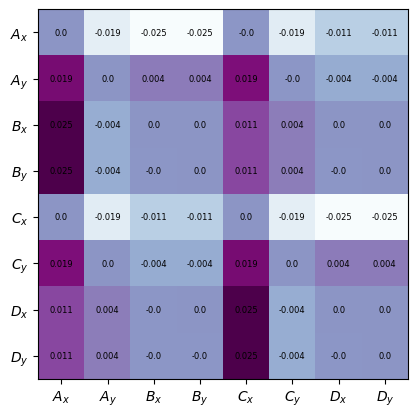

In [13]:
plt.xticks( np.arange(0, tb.norb), 
           [r'$A_{x  }$', r'$A_{y  }$', r'$B_{x  }$', r'$B_{y  }$',r'$C_{x  }$', r'$C_{y  }$',r'$D_{x  }$', r'$D_{y  }$',r'$E_{x  }$', r'$E_{y  }$',r'$F_{x  }$', r'$F_{y  }$',r'$G_{x  }$', r'$G_{y  }$',r'$H_{x  }$', r'$H_{y  }$',r'$I_{x  }$', r'$I_{y  }$',r'$J_{x  }$', r'$J_{y  }$',r'$K_{x  }$', r'$K_{y  }$',r'$L_{x  }$', r'$L_{y  }$',r'$M_{x  }$', r'$M_{y  }$',r'$N_{x  }$', r'$N_{y  }$',r'$O_{x  }$', r'$O_{y  }$',r'$P_{x  }$', r'$P_{y  }$',r'$Q_{x  }$', r'$Q_{y  }$',r'$R_{x  }$', r'$R_{y  }$' ][:tb.norb] )
plt.yticks( np.arange(0, tb.norb), 
           [r'$A_{x  }$', r'$A_{y  }$', r'$B_{x  }$', r'$B_{y  }$',r'$C_{x  }$', r'$C_{y  }$',r'$D_{x  }$', r'$D_{y  }$',r'$E_{x  }$', r'$E_{y  }$',r'$F_{x  }$', r'$F_{y  }$',r'$G_{x  }$', r'$G_{y  }$',r'$H_{x  }$', r'$H_{y  }$',r'$I_{x  }$', r'$I_{y  }$',r'$J_{x  }$', r'$J_{y  }$',r'$K_{x  }$', r'$K_{y  }$',r'$L_{x  }$', r'$L_{y  }$',r'$M_{x  }$', r'$M_{y  }$',r'$N_{x  }$', r'$N_{y  }$',r'$O_{x  }$', r'$O_{y  }$',r'$P_{x  }$', r'$P_{y  }$',r'$Q_{x  }$', r'$Q_{y  }$',r'$R_{x  }$', r'$R_{y  }$' ][:tb.norb] )
plt.imshow(qgtxx_indirect_asym,cmap="BuPu")
for n in np.arange(0,int(tb.norb)):
    for m in np.arange(0,int(tb.norb)):
        number = np.round(np.real(qgtxx_indirect_asym)[n,m],3)
        plt.text(m, n, number, va='center', ha='center',fontsize=6)
#Try fourier transforming?? (discrete fourier transform)

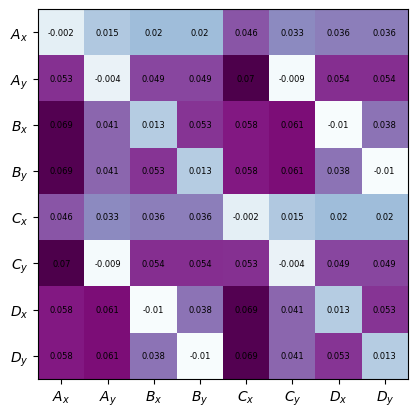

In [14]:
plt.xticks( np.arange(0, tb.norb), 
           [r'$A_{x  }$', r'$A_{y  }$', r'$B_{x  }$', r'$B_{y  }$',r'$C_{x  }$', r'$C_{y  }$',r'$D_{x  }$', r'$D_{y  }$',r'$E_{x  }$', r'$E_{y  }$',r'$F_{x  }$', r'$F_{y  }$',r'$G_{x  }$', r'$G_{y  }$',r'$H_{x  }$', r'$H_{y  }$',r'$I_{x  }$', r'$I_{y  }$',r'$J_{x  }$', r'$J_{y  }$',r'$K_{x  }$', r'$K_{y  }$',r'$L_{x  }$', r'$L_{y  }$',r'$M_{x  }$', r'$M_{y  }$',r'$N_{x  }$', r'$N_{y  }$',r'$O_{x  }$', r'$O_{y  }$',r'$P_{x  }$', r'$P_{y  }$',r'$Q_{x  }$', r'$Q_{y  }$',r'$R_{x  }$', r'$R_{y  }$' ][:tb.norb] )
plt.yticks( np.arange(0, tb.norb), 
           [r'$A_{x  }$', r'$A_{y  }$', r'$B_{x  }$', r'$B_{y  }$',r'$C_{x  }$', r'$C_{y  }$',r'$D_{x  }$', r'$D_{y  }$',r'$E_{x  }$', r'$E_{y  }$',r'$F_{x  }$', r'$F_{y  }$',r'$G_{x  }$', r'$G_{y  }$',r'$H_{x  }$', r'$H_{y  }$',r'$I_{x  }$', r'$I_{y  }$',r'$J_{x  }$', r'$J_{y  }$',r'$K_{x  }$', r'$K_{y  }$',r'$L_{x  }$', r'$L_{y  }$',r'$M_{x  }$', r'$M_{y  }$',r'$N_{x  }$', r'$N_{y  }$',r'$O_{x  }$', r'$O_{y  }$',r'$P_{x  }$', r'$P_{y  }$',r'$Q_{x  }$', r'$Q_{y  }$',r'$R_{x  }$', r'$R_{y  }$' ][:tb.norb] )
plt.imshow(qgtxx_indirect,cmap="BuPu")
for n in np.arange(0,int(tb.norb)):
    for m in np.arange(0,int(tb.norb)):
        number = np.round(np.real(qgtxx_indirect)[n,m],3)
        plt.text(m, n, number, va='center', ha='center',fontsize=6)
#Try fourier transforming?? (discrete fourier transform)

In [23]:
mu=mu
def solve_cohp_energy_resolved():		
    en_array = np.linspace(np.min(tb.enUM[:,:,0]),np.max(tb.enUM[:,:,0]),100)
    COHP = np.zeros([np.size(tb.kSpan[:,0]), tb.norb, tb.norb,tb.norb], dtype=complex)
    for i, k in enumerate(tb.kSpan):
        ham_k = tb.ham(k)
        um = tb.enUM[i, :, 1:]  # shape: (norb, norb) #order is k,orb,band
        for j in range(tb.norb):
            COHP[i,:,:,j] = np.abs(um[:,j] @ np.conj(um[:,j]).T)*ham_k
    #to plot as historgram: 
    # hist,bin_edges = np.histogram(tb.enUM[:, :, 0].ravel(),weights =COHP[i,j].ravel(),bins=100)
    return COHP
COHP = solve_cohp_energy_resolved()#/np.size(tb.kSpan[:,0])
filled_mask = np.zeros_like(tb.enUM[:,:,0])
filled_mask[tb.enUM[:,:,0]<mu] = 1
COHP_filled = np.zeros((tb.norb,tb.norb))
for alpha in range(tb.norb):
    for beta in range(tb.norb):
        COHP_filled[alpha,beta] = np.sum(filled_mask*COHP[:,alpha,beta,:])/(len(tb.kSpan))

/tmp/ipykernel_3568065/2438909493.py:19: ComplexWarning: Casting complex values to real discards the imaginary part
  COHP_filled[alpha,beta] = np.sum(filled_mask*COHP[:,alpha,beta,:])/(len(tb.kSpan))


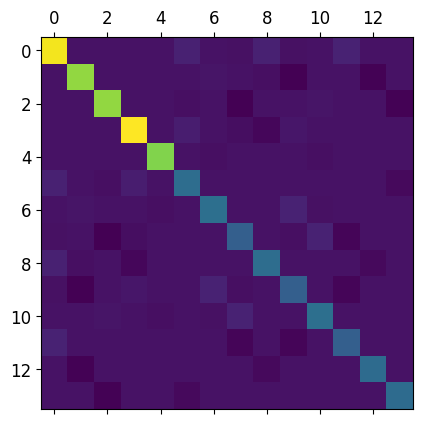

In [26]:
plt.matshow(COHP_filled-mu)

In [22]:
COHP_atom_resolved = np.zeros((int(tb.norb/2),int(tb.norb/2)))
for a in range(int(tb.norb/2)):
    for b in range(int(tb.norb/2)):
        COHP_atom_resolved[a,b]=COHP_filled[a*2,b*2]+COHP_filled[a*2,b*2+1]+COHP_filled[a*2+1,b*2]+COHP_filled[a*2+1,b*2+1]
norm = mpl.colors.Normalize(vmin=np.min(np.real(-COHP_atom_resolved)), vmax=np.max(np.real(-COHP_atom_resolved)))
plt.xticks( np.arange(0, int(tb.norb/2)), 
           [r'$A$',r'$B$',r'$C$', r'$D$',r'$E$',r'$F$',r'$G$',r'$H$',r'$I$',r'$J$'][:int(tb.norb/2)] )
plt.yticks( np.arange(0, int(tb.norb/2)), 
           [r'$A$',r'$B$',r'$C$', r'$D$',r'$E$',r'$F$',r'$G$',r'$H$',r'$I$',r'$J$'][:int(tb.norb/2)] )
im = plt.imshow(-COHP_atom_resolved,norm=norm,cmap="YlOrRd")
cbar = plt.colorbar(im)

for n in np.arange(0,int(tb.norb/2)):
    for m in np.arange(0,int(tb.norb/2)):
        number = np.round(np.real(-COHP_atom_resolved)[n,m],3)
        plt.text(m, n, number, va='center', ha='center',fontsize=7)

for n in np.arange(0,int(tb.norb/2)):
    plt.axhline(n-0.5,color="grey")
    plt.axvline(n-0.5,color="grey")
plt.title(r"-COHP Fivefold Onsite")
#nkpx,g,gxx,gyy 5 5.758276455584362 2.487193224645975 3.2710832309383866
#plt.savefig("/Users/gcarrel/Documents/SCHOOP/Distorted_Square_Net/_images/COHP_Fivefold_onsite_atomres.png",dpi=300)


NameError: name 'COHP_filled' is not defined

In [27]:

def solve_1pRDM_kresolved(mu):
    OpRDM = np.zeros([len(tb.kSpan), tb.norb, tb.norb], dtype=complex)		
    for i, k in enumerate(tb.kSpan):
        en = tb.enUM[i, :, 0]
        um = tb.enUM[i, :, 1:]  # shape: (norb, norb) #order is k,orb,band
        for band in range(tb.norb):
            enband = en[band]
            if enband < mu:
                bandWF = um[:,band][:,np.newaxis]#um[:, band].reshape(-1, 1)  # ensure column vector
                OpRDM[i, :, :] += bandWF @ bandWF.conj().T
            
    return OpRDM

In [13]:
np.save('/projects/SCHOOP/gc2596/Wannier_test/AlP/wannier/QM_orb_res_qgtxx.npy', qgtxx/denom)
np.save('/projects/SCHOOP/gc2596/Wannier_test/AlP/wannier/QM_orb_res_qgtyy.npy', qgtyy/denom)
np.save('/projects/SCHOOP/gc2596/Wannier_test/AlP/wannier/QM_orb_res_qgtxy.npy', qgtxy/denom)
np.save('/projects/SCHOOP/gc2596/Wannier_test/AlP/wannier/QM_orb_res_qgtyx.npy', qgtxx/denom)

In [29]:
from pymatgen.core import Structure
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer

# Path to your POSCAR file
poscar_path = "/projects/SCHOOP/gc2596/ipynb_notebooks/hoffmann/LaTe3/conv_to_prim/CONVCELL.vasp"

# Load structure
structure = Structure.from_file(poscar_path)

# Run symmetry analysis
sga = SpacegroupAnalyzer(structure)

# Get symmetry dataset
symm_struct = sga.get_symmetrized_structure()

print("Space group:", sga.get_space_group_symbol(), sga.get_space_group_number())
print()

# Wyckoff positions for each atom
wyckoffs = symm_struct.wyckoff_symbols
equiv_indices = symm_struct.equivalent_indices

for group, wyck in zip(equiv_indices, wyckoffs):
    for i in group:
        site = structure[i]
        print(
            f"Atom index: {i:3d} | "
            f"Element: {site.species_string:2s} | "
            f"Wyckoff: {wyck} | "
            f"Frac coords: {site.frac_coords}"
        )

Space group: Cmcm 63

Atom index:   0 | Element: La | Wyckoff: 4c | Frac coords: [0.5        0.32947346 0.25      ]
Atom index:   1 | Element: La | Wyckoff: 4c | Frac coords: [0.         0.17052654 0.75      ]
Atom index:   2 | Element: La | Wyckoff: 4c | Frac coords: [0.         0.82947346 0.25      ]
Atom index:   3 | Element: La | Wyckoff: 4c | Frac coords: [0.5        0.67052654 0.75      ]
Atom index:   4 | Element: Te | Wyckoff: 4c | Frac coords: [0.         0.07347856 0.25      ]
Atom index:   5 | Element: Te | Wyckoff: 4c | Frac coords: [0.5        0.42652144 0.75      ]
Atom index:  10 | Element: Te | Wyckoff: 4c | Frac coords: [0.5        0.57347856 0.25      ]
Atom index:  11 | Element: Te | Wyckoff: 4c | Frac coords: [0.         0.92652144 0.75      ]
Atom index:   6 | Element: Te | Wyckoff: 4c | Frac coords: [0.         0.42663178 0.25      ]
Atom index:   7 | Element: Te | Wyckoff: 4c | Frac coords: [0.5        0.07336822 0.75      ]
Atom index:  12 | Element: Te | Wyckof